# 07 · Wine Quality — The Class-Imbalance Problem (class weights, SMOTE, the tradeoff)

## Part 7 — The Class-Imbalance Problem

Every model so far has **ignored the tails** — Part 5 measured ~4% recall on the rare grades (3, 4, 8,
9). That's rational under a plain loss: with a handful of examples, never predicting them is the safe
bet. But if we *care* about spotting an exceptional or a faulty wine, we must intervene. Three classic
remedies, and an honest accounting of what each buys and costs:

- **Class weights** — tell the loss to count a rare-grade mistake more heavily.
- **Random oversampling** — duplicate minority rows until classes are balanced.
- **SMOTE** — synthesise *new* minority examples by interpolating between real ones.

The question isn't "do they raise recall" (they do) but **"what do they cost, and is there a
ceiling?"**

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import modeling as M
from lightgbm import LGBMClassifier
from sklearn.metrics import recall_score, f1_score
from imblearn.over_sampling import SMOTE, RandomOverSampler
raw = data.clean(); Xtr, Xte, ytr, yte = M.split(raw)
LG = dict(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=0, verbose=-1, n_jobs=-1)
print("train counts:", ytr.value_counts().sort_index().to_dict())
print("-> grade 9 has just", (ytr==9).sum(), "training examples. Remember this number.")

setup ok | numpy 2.1.3 | pandas 2.3.3


train counts: {3: 22, 4: 155, 5: 1314, 6: 1742, 7: 642, 8: 111, 9: 4}
-> grade 9 has just 4 training examples. Remember this number.


### 1. Balancing the training set

SMOTE and random oversampling both rebalance every grade to the size of the majority class (here
~1,742 each). The difference: oversampling **copies** rare wines (risking overfitting to those exact
points), while SMOTE **interpolates** new synthetic wines between neighbours (more diverse, but it
invents chemistry that never existed — and can't conjure signal from 4 grade-9 points).

In [2]:
kmin = ytr.value_counts().min() - 1
Xs, ys = SMOTE(random_state=0, k_neighbors=min(3, max(1, kmin))).fit_resample(Xtr, ytr)
Xo, yo = RandomOverSampler(random_state=0).fit_resample(Xtr, ytr)
print("after SMOTE:           ", pd.Series(ys).value_counts().sort_index().to_dict())
print("after random oversample:", pd.Series(yo).value_counts().sort_index().to_dict())

after SMOTE:            {3: 1742, 4: 1742, 5: 1742, 6: 1742, 7: 1742, 8: 1742, 9: 1742}
after random oversample: {3: 1742, 4: 1742, 5: 1742, 6: 1742, 7: 1742, 8: 1742, 9: 1742}


### 2. The scoreboard — four metrics, four strategies

`rare_recall` averages recall over grades {3,4,8,9}. The pattern here is encouraging *and* sobering:
every remedy lifts rare-recall, macro-F1 **and** QWK — so balancing is a net win under the right
metric — but it shaves a little **accuracy**, and the rare-recall numbers stay low in absolute terms.

                QWK  macro_F1  rare_recall  accuracy
none          0.494     0.262        0.037     0.550
class_weight  0.519     0.277        0.058     0.541
random_over   0.513     0.283        0.063     0.547
SMOTE         0.523     0.297        0.114     0.534


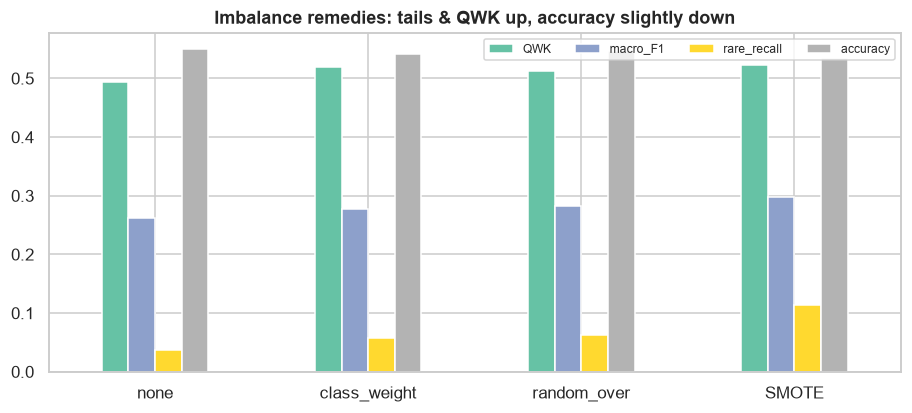

In [3]:
def evals(yp, name):
    return pd.Series({"QWK": M.qwk(yte, yp),
                      "macro_F1": f1_score(yte, yp, average="macro", zero_division=0),
                      "rare_recall": recall_score(yte, yp, labels=[3,4,8,9], average="macro", zero_division=0),
                      "accuracy": (yp == yte.values).mean()}, name=name).round(3)
preds = {}
preds["none"]        = LGBMClassifier(**LG).fit(Xtr, ytr).predict(Xte)
preds["class_weight"]= LGBMClassifier(class_weight="balanced", **LG).fit(Xtr, ytr).predict(Xte)
preds["random_over"] = LGBMClassifier(**LG).fit(Xo, yo).predict(Xte)
preds["SMOTE"]       = LGBMClassifier(**LG).fit(Xs, ys).predict(Xte)
board = pd.DataFrame([evals(p, n) for n, p in preds.items()])
print(board.to_string())
fig, ax = plt.subplots(figsize=(10, 4))
board[["QWK","macro_F1","rare_recall","accuracy"]].plot.bar(ax=ax, rot=0, colormap="Set2")
ax.set_title("Imbalance remedies: tails & QWK up, accuracy slightly down"); ax.legend(loc="upper right", ncol=4, fontsize=8)
eda.savefig(fig, "p7_scoreboard.png"); plt.show()

### 3. *Where* the gain happens — per-grade recall

Averages hide the mechanism. Comparing baseline vs SMOTE recall **grade by grade** shows the lift is
concentrated in the **tails** (grades 4 and 8 improve most; the common 5/6 dip slightly as the model
stops over-betting on them). But grades **3 and 9 stay near zero** — no amount of resampling fixes
*4 training examples*. This is the **ceiling**: imbalance methods redistribute attention, they don't
create information.

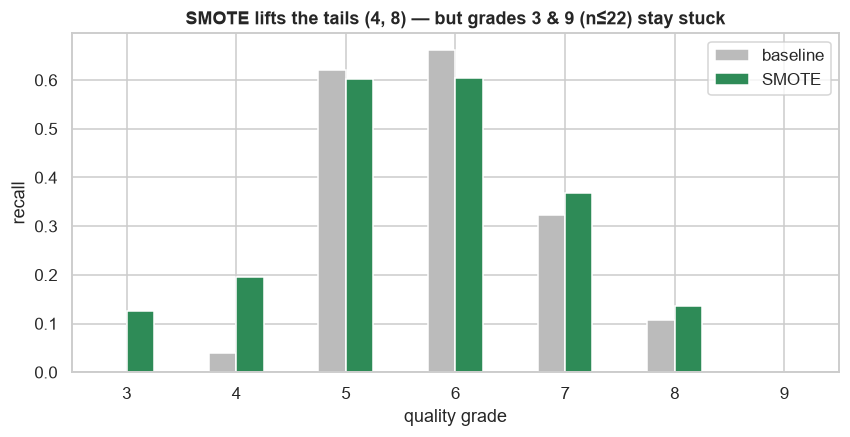

   baseline  SMOTE
3      0.00   0.12
4      0.04   0.20
5      0.62   0.60
6      0.66   0.60
7      0.32   0.37
8      0.11   0.14
9      0.00   0.00


In [4]:
g = list(range(3,10))
rec_base = recall_score(yte, preds["none"],  labels=g, average=None, zero_division=0)
rec_smote= recall_score(yte, preds["SMOTE"], labels=g, average=None, zero_division=0)
comp = pd.DataFrame({"baseline": rec_base, "SMOTE": rec_smote}, index=g)
fig, ax = plt.subplots(figsize=(9, 4))
comp.plot.bar(ax=ax, color=["#bbb","seagreen"], rot=0); ax.set_xlabel("quality grade"); ax.set_ylabel("recall")
ax.set_title("SMOTE lifts the tails (4, 8) — but grades 3 & 9 (n≤22) stay stuck")
eda.savefig(fig, "p7_pergrade.png"); plt.show()
print(comp.round(2).to_string())

### 4. The honest verdict

So is balancing worth it? **It depends what you optimise for.** If the rare wines matter (flagging
faulty or exceptional bottles), SMOTE's 3× rare-recall and higher QWK justify the ~1.5-point accuracy
hit. If only overall correctness matters, the gain is marginal. Two caveats to carry forward:
*(1)* the absolute rare-recall is still poor — collect more extreme-grade data, don't expect SMOTE to
rescue it; *(2)* resampling **distorts the class proportions**, so the model's predicted
*probabilities* no longer match reality — exactly the problem Part 8 (calibration) examines.

In [5]:
best = board.QWK.idxmax()
print("best QWK strategy: %s (%.3f vs none %.3f)" % (board.loc[best].name, board.QWK.max(), board.loc["none","QWK"]))
print("rare-recall: none %.3f -> SMOTE %.3f  (%.1fx)  | accuracy cost: %.3f" %
      (board.loc["none","rare_recall"], board.loc["SMOTE","rare_recall"],
       board.loc["SMOTE","rare_recall"]/max(board.loc["none","rare_recall"],1e-9),
       board.loc["none","accuracy"] - board.loc["SMOTE","accuracy"]))

best QWK strategy: SMOTE (0.523 vs none 0.494)
rare-recall: none 0.037 -> SMOTE 0.114  (3.1x)  | accuracy cost: 0.016


### Takeaways

- The rare-grade collapse is a **loss-incentive** problem; class weights / oversampling / SMOTE all
  push the model to attend to minorities.
- Here every remedy **improves QWK, macro-F1 and rare-recall** at a small accuracy cost — under QWK,
  balancing is a net win (SMOTE best). The "no free lunch" shows up as **accuracy vs the tails**.
- There's a hard **ceiling**: grades 3 and 9 (n ≤ 22 in train) stay near 0% recall — resampling
  redistributes attention, it can't invent signal. *More data* is the only real fix for those.
- Resampling **distorts predicted probabilities** → calibrate before trusting them (Part 8).

**Next — Part 8 (Probability calibration):** when the model says "70% chance this is a 6," is it right
70% of the time? Reliability curves, and fixing miscalibration with isotonic / Platt scaling.